In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,Dropout
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [62]:
df=pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_test_label= pd.read_csv('sample_submission_redesigned.csv')

In [63]:
df.shape

(42000, 785)

In [64]:
df_test.shape

(28000, 784)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [66]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


In [67]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [69]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.values
y_test = df_test_label['Label'].values

In [70]:
df_test_label['Label'].value_counts()

Label
1    3289
4    3003
7    2903
8    2777
3    2756
0    2740
6    2684
2    2651
9    2610
5    2587
Name: count, dtype: int64

In [71]:
X_train = X_train/255.0
X_test = X_test/255.0

In [72]:
x_train_resape = X_train.reshape(-1,28,28)
x_test_resape = X_test.reshape(-1,28,28)

In [73]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(42000, 784))

In [74]:
x_train_resape.shape

(42000, 28, 28)

In [75]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [76]:
y_train_cat

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(42000, 10))

In [77]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])

In [78]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [79]:
history_per = model.fit(x_train_resape,y_train_cat,
            epochs=20,batch_size=32,
            validation_data=(x_test_resape,y_test_cat),verbose=1)

Epoch 1/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8655 - loss: 0.5216 - val_accuracy: 0.9439 - val_loss: 0.2322
Epoch 2/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9119 - loss: 0.3152 - val_accuracy: 0.9503 - val_loss: 0.1867
Epoch 3/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9192 - loss: 0.2882 - val_accuracy: 0.9532 - val_loss: 0.1701
Epoch 4/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9230 - loss: 0.2746 - val_accuracy: 0.9542 - val_loss: 0.1616
Epoch 5/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9259 - loss: 0.2659 - val_accuracy: 0.9550 - val_loss: 0.1566
Epoch 6/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9272 - loss: 0.2596 - val_accuracy: 0.9553 - val_loss: 0.1533
Epoch 7/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9282 - loss: 0.2547 - val_accuracy: 0.9558 - val_loss: 0.1510
Epoch 8/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9292 - loss: 0.2507 - 

In [80]:
acc_perceptron = model.evaluate(x_test_resape,y_test_cat,verbose=1)[1]

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9539 - loss: 0.1464


In [81]:
acc_perceptron

0.9538928866386414

# **ANN**

In [82]:
#ANN
ann_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [83]:
ann_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [84]:
# history_ann = ann_model.fit(x_train_resape,y_train_cat,epochs=10,batch_size=32,
#                             validation_data=(x_test_resape,y_test_cat),verbose=1)

In [85]:
history_ann = ann_model.fit(
    x_train_resape,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9104 - loss: 0.2995 - val_accuracy: 0.9537 - val_loss: 0.1490
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9624 - loss: 0.1249 - val_accuracy: 0.9633 - val_loss: 0.1172
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9762 - loss: 0.0807 - val_accuracy: 0.9677 - val_loss: 0.1028
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9827 - loss: 0.0564 - val_accuracy: 0.9693 - val_loss: 0.1020
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9882 - loss: 0.0403 - val_accuracy: 0.9671 - val_loss: 0.1195
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9643 - val_loss: 0.1256
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9910 - loss: 0.0273 - val_accuracy: 0.9719 - val_loss: 0.1098
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9930 - loss: 0.0218 - 

In [106]:
ann_acc = ann_model.evaluate(x_test_resape, y_test_cat, verbose=0)[1]

In [87]:
history_ann.history

{'accuracy': [0.9104464054107666,
  0.9623809456825256,
  0.9762202501296997,
  0.9827380776405334,
  0.9881547689437866,
  0.9895535707473755,
  0.9910416603088379,
  0.9930059313774109,
  0.9932143092155457,
  0.9939285516738892],
 'loss': [0.29946136474609375,
  0.12486515939235687,
  0.08065715432167053,
  0.056415192782878876,
  0.040275029838085175,
  0.03363152593374252,
  0.027335694059729576,
  0.02181043103337288,
  0.020305827260017395,
  0.017463840544223785],
 'val_accuracy': [0.9536904692649841,
  0.9633333086967468,
  0.9677380919456482,
  0.9692857265472412,
  0.9671428799629211,
  0.9642857313156128,
  0.9719047546386719,
  0.9678571224212646,
  0.9746428728103638,
  0.9753571152687073],
 'val_loss': [0.14901617169380188,
  0.11724374443292618,
  0.1027788296341896,
  0.1020258441567421,
  0.11945977807044983,
  0.12564924359321594,
  0.10980265587568283,
  0.1325748711824417,
  0.10953768342733383,
  0.1061650812625885]}

# **CNN**

In [88]:
x_train_cnn = X_train.reshape(-1,28,28,1)
x_test_cnn = X_test.reshape(-1,28,28,1)

In [89]:
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [90]:
cnn_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [91]:
history_cnn = cnn_model.fit(x_train_cnn,y_train_cat,epochs=10,batch_size=32,
                            validation_data=(x_test_cnn,y_test_cat),verbose=1)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9279 - loss: 0.2348 - val_accuracy: 0.9155 - val_loss: 0.4981
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9744 - loss: 0.0856 - val_accuracy: 0.9127 - val_loss: 0.5670
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9818 - loss: 0.0627 - val_accuracy: 0.9116 - val_loss: 0.6824
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9840 - loss: 0.0511 - val_accuracy: 0.9119 - val_loss: 0.7623
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9874 - loss: 0.0412 - val_accuracy: 0.9106 - val_loss: 0.8544
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9885 - loss: 0.0371 - val_accuracy: 0.9115 - val_loss: 0.9025
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9910 - loss: 0.0294 - val_accuracy: 0.9108 - val_loss: 1.0368
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9914 -

In [92]:
accuracy_score_cnn = cnn_model.evaluate(x_test_cnn,y_test_cat)[1]

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9113 - loss: 1.1881


In [93]:
accuracy_score_cnn 

0.9112856984138489

In [94]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

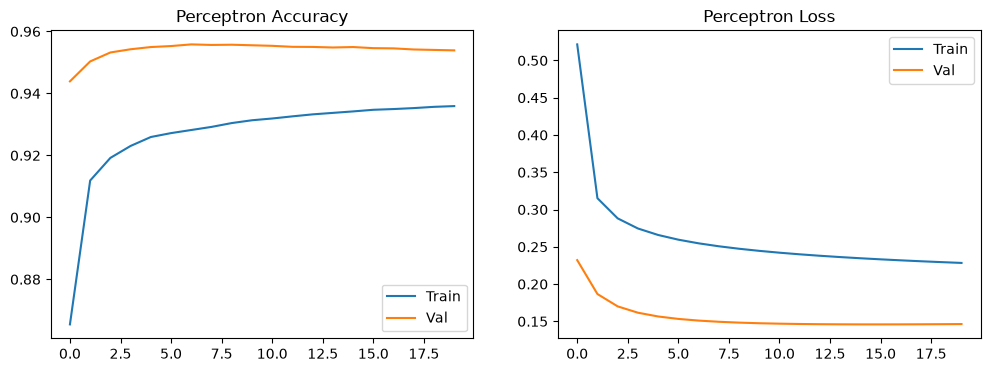

In [95]:
plot_training(history_per, "Perceptron")

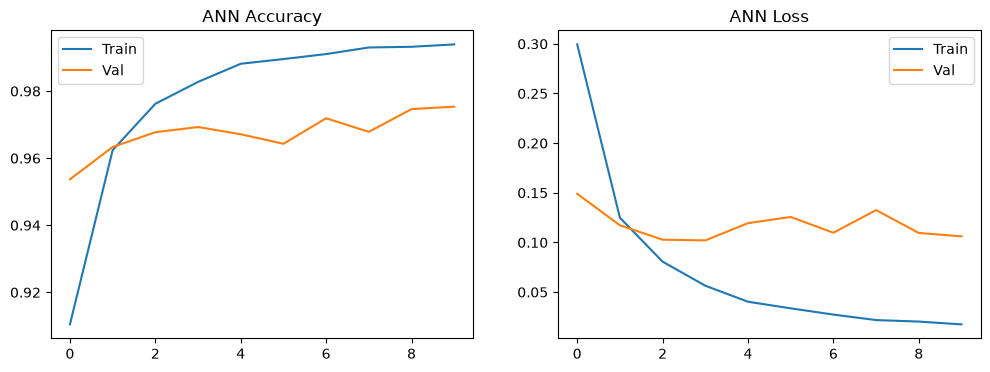

In [96]:

plot_training(history_ann, "ANN")

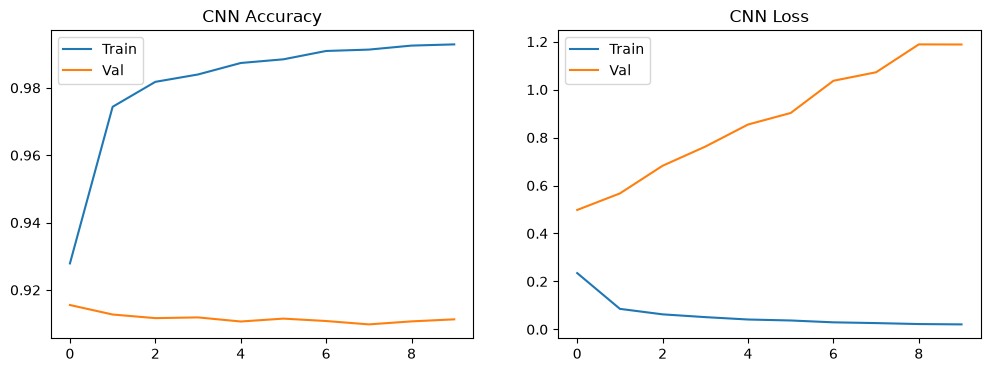

In [97]:

plot_training(history_cnn, "CNN")

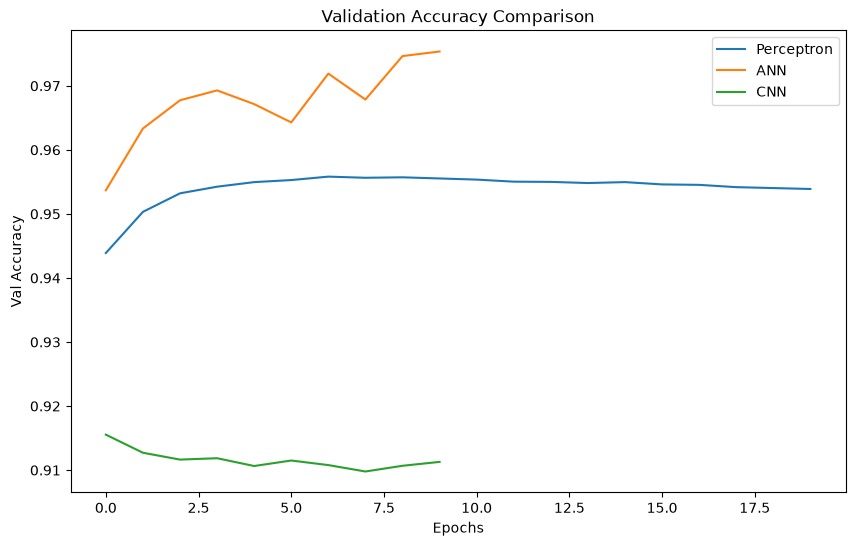

In [98]:
plt.figure(figsize=(10,6))
plt.plot(history_per.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [99]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


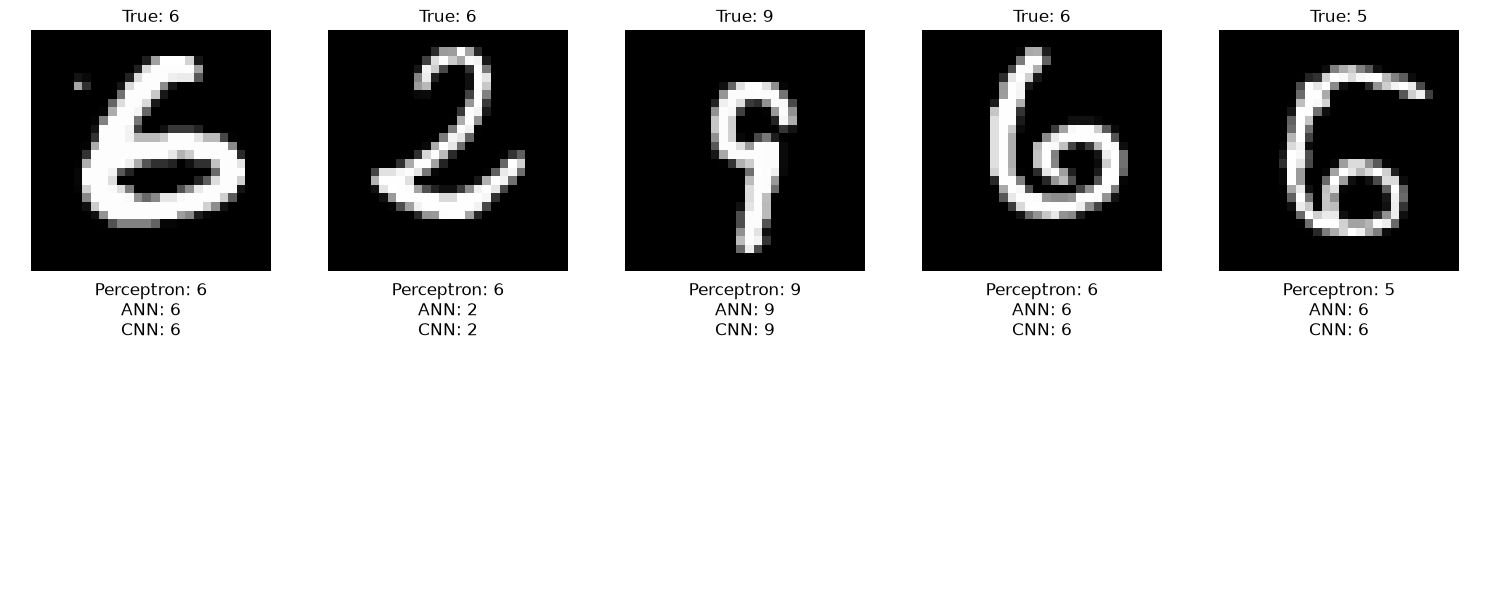

In [100]:

show_side_by_side([model, ann_model, cnn_model], ["Perceptron", "ANN", "CNN"], x_test_resape, x_test_cnn, y_test, 5)

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


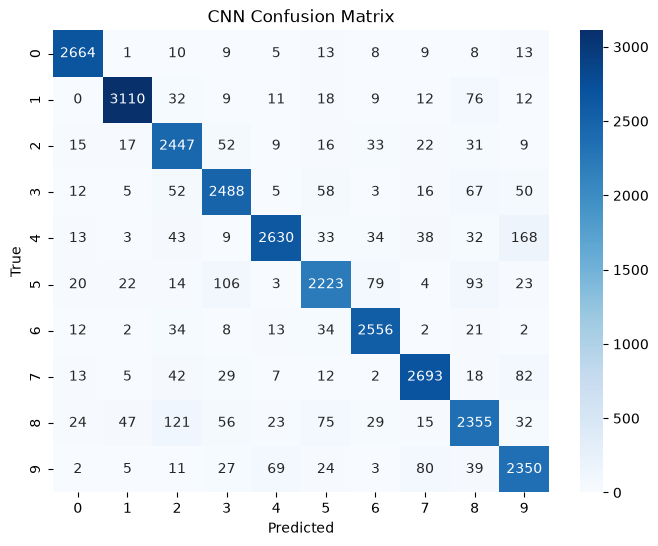

In [101]:
y_pred_cnn = np.argmax(cnn_model.predict(x_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

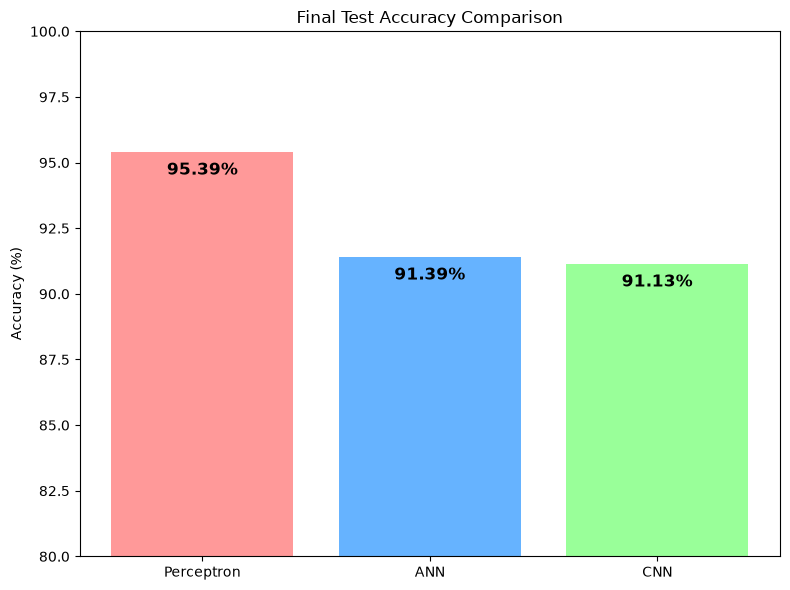

In [107]:
final_accs = [
    acc_perceptron * 100,
    ann_acc * 100,
    accuracy_score_cnn * 100
]

models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    models,
    final_accs,
    color=['#ff9999', '#66b3ff', '#99ff99']
)

plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")

for bar, acc in zip(bars, final_accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 1,
        f"{acc:.2f}%",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.ylim(80, 100)
plt.tight_layout()
plt.show()